In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

df = pd.read_csv('Car_Insurance_Claim.csv')

df.drop('ID', axis=1, inplace=True)
df.drop('RACE', axis=1, inplace=True)

print(df.head())

     AGE  GENDER DRIVING_EXPERIENCE    EDUCATION         INCOME  CREDIT_SCORE  \
0    65+  female               0-9y  high school    upper class      0.629027   
1  16-25    male               0-9y         none        poverty      0.357757   
2  16-25  female               0-9y  high school  working class      0.493146   
3  16-25    male               0-9y   university  working class      0.206013   
4  26-39    male             10-19y         none  working class      0.388366   

   VEHICLE_OWNERSHIP VEHICLE_YEAR  MARRIED  CHILDREN  POSTAL_CODE  \
0                  1   after 2015        0         1        10238   
1                  0  before 2015        0         0        10238   
2                  1  before 2015        0         0        10238   
3                  1  before 2015        0         1        32765   
4                  1  before 2015        0         0        32765   

   ANNUAL_MILEAGE VEHICLE_TYPE  SPEEDING_VIOLATIONS  DUIS  PAST_ACCIDENTS  \
0         12000.0    

In [ ]:
# در ابتدا تعداد رکورد های موجود را بدست آورده و نمایش میدهیم
total_rows = df.shape[0]
print(f"Number of records : {total_rows} \n")

# به صورت میانگین تعداد خانه های خالی در هر سطر را به دست می آوریم
missing_per_row = df.isnull().sum(axis=1)
avg_missing_per_row = missing_per_row.mean()
print(f"Average of missing info per row : {avg_missing_per_row:.2f} \n")

Number of records : 10000 

Average of missing info per row : 0.19 



In [4]:
# مشخص میکنیم کدام متغیر هایمان عددی هستند و کدام غیر عددی

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric variables : {numeric_cols}")
print(f"Non-numeric variables : {categorical_cols}")

Numeric variables : ['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN', 'POSTAL_CODE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS', 'OUTCOME']
Non-numeric variables : ['AGE', 'GENDER', 'DRIVING_EXPERIENCE', 'EDUCATION', 'INCOME', 'VEHICLE_YEAR', 'VEHICLE_TYPE']


In [5]:
# تعداد و درصد موارد اعلام خسارت شده را بررسی می کنیم

outcome_counts = df['OUTCOME'].value_counts()
outcome_percent = df['OUTCOME'].value_counts(normalize=True) * 100

print("Number of reported damage :")
for val, cnt in outcome_counts.items():
    print(f"  OUTCOME = {val} : {cnt}")

print("Percentage of reported damage :")
for val, pct in outcome_percent.items():
    print(f"  OUTCOME = {val} : {pct:.2f}%")

Number of reported damage :
  OUTCOME = 0 : 6867
  OUTCOME = 1 : 3133
Percentage of reported damage :
  OUTCOME = 0 : 68.67%
  OUTCOME = 1 : 31.33%


In [6]:
# بررسی می کنیم که آیا داده ای که داریم بالانس و متوازن است یا خیر
# بالانس بودن یعنی تعداد نمونه‌های هر کلاس (مثلاً خسارت دیده و ندیده) تقریباً برابر باشد
# نامتوازن یعنی یک کلاس خیلی بیشتر از کلاس دیگر نمونه دارد که ممکن است باعث اریب شدن نتایج شود

if abs(outcome_percent[1] - 50) < 15:
    print("Result: Data is relatively balanced (difference less than 15%).")
else:
    print("Result: Data is imbalanced (balancing required).")

Result: Data is imbalanced (balancing required).


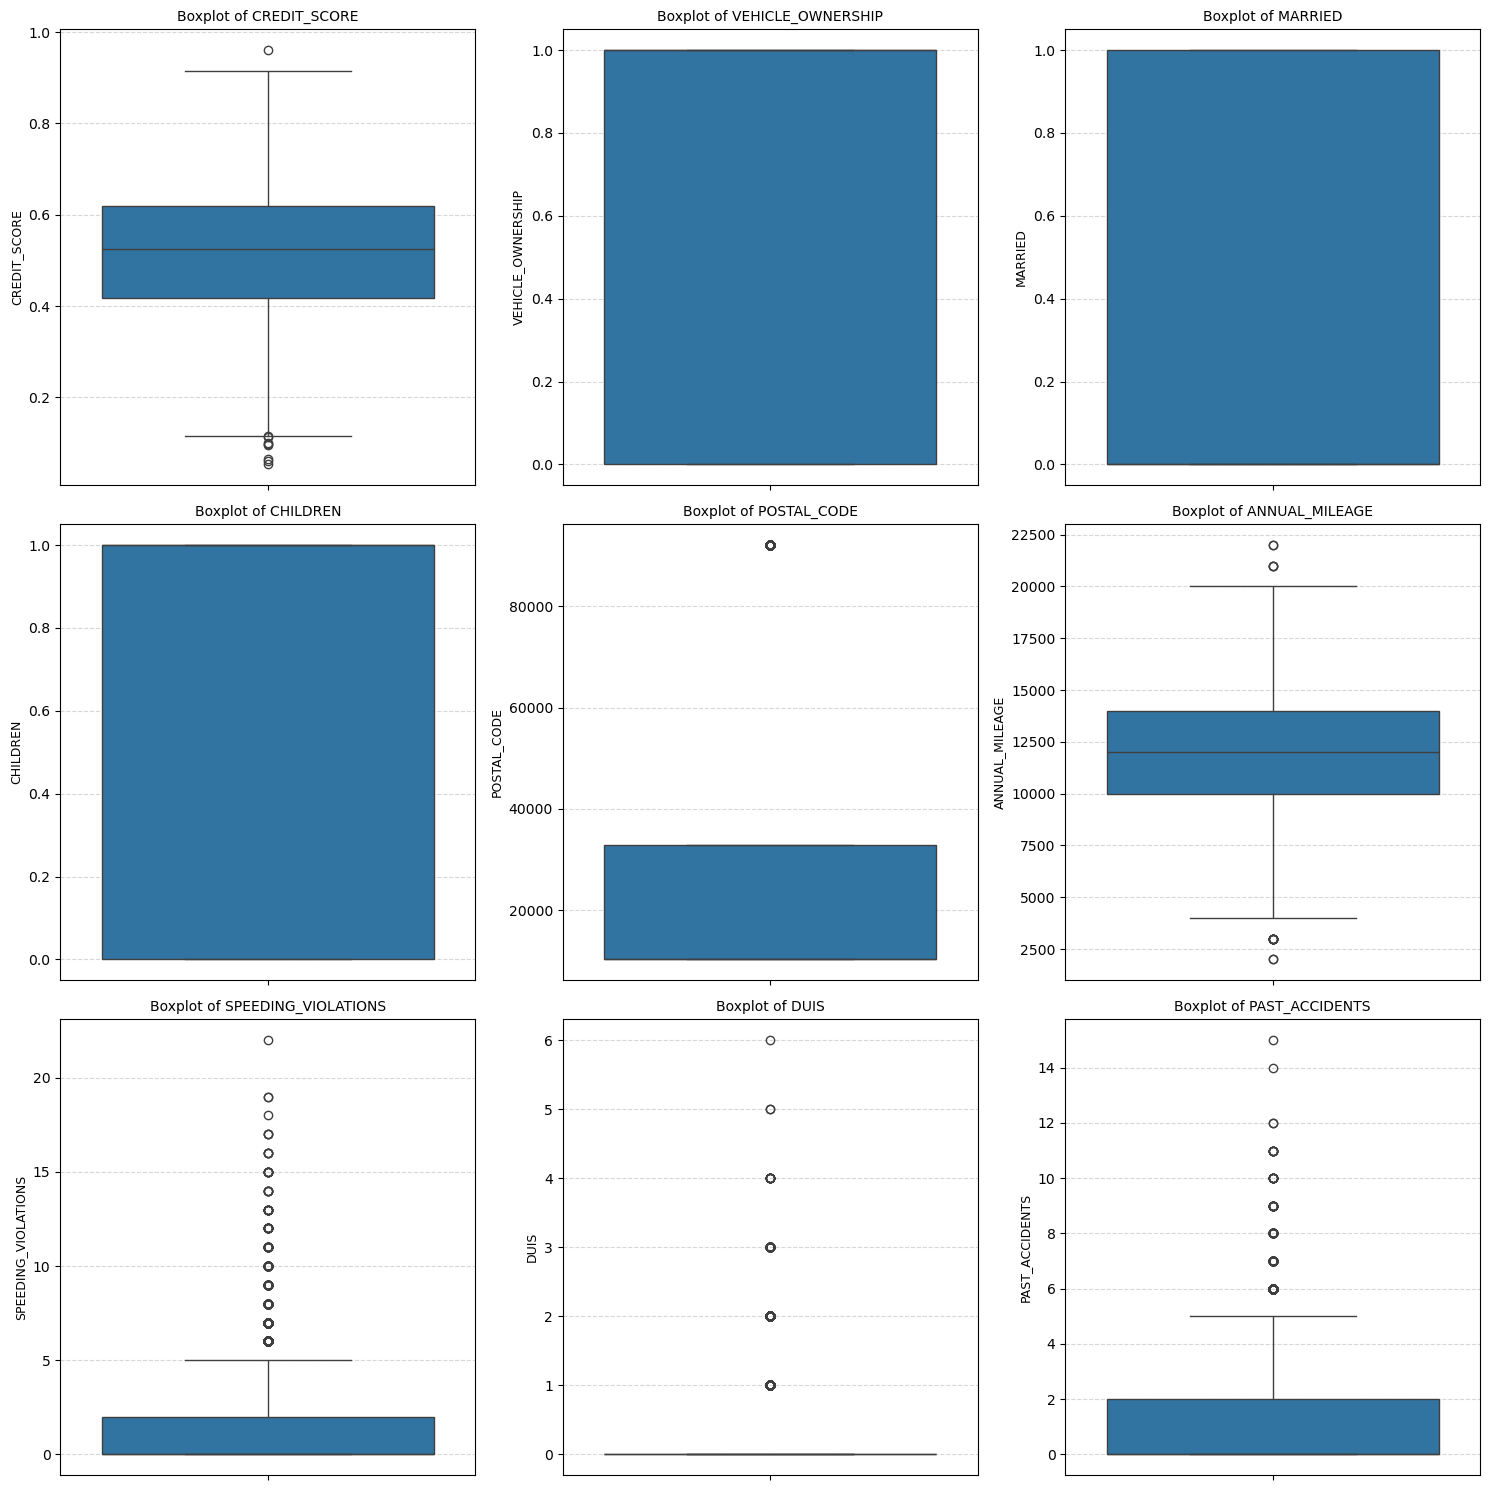

In [ ]:
# ابتدا دامنه میان چارکی هر ستون را محاسبه می کنیم و سپس باکس پلات آنها را حذف می کنیم
# برای ستون خروجی جدول رسم نمیکنیم زیرا متغیر پاسخ است

# این تابع برای هر دیتافریم تعداد داده های پرت را براساس روش باکس پلات برمیگرداند
def iqr_outlier_summary(df, col):
    Q1 = df[col].quantile(0.25)                     #چارک اول
    Q3 = df[col].quantile(0.75)                     #چارک سوم
    IQR = Q3 - Q1                                   #دامنه میان چارکی
    lower_bound = Q1 - 1.5 * IQR                    #کران پایین
    upper_bound = Q3 + 1.5 * IQR                    #کران بالا  
    
    # تعداد ردیف‌هایی که خارج از این کران‌ها هستند
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df)) * 100
    return {
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        '# Outliers': n_outliers,
        '% Outliers': round(pct_outliers, 2)
    }

# اطلاعات بدست آمده را در یک لیست ذخیره سازی میکنیم
summary_list = []
for col in numeric_cols:
    summary_list.append(iqr_outlier_summary(df, col))

plot_cols = [col for col in numeric_cols if col != 'OUTCOME']

# رسم باکس پلات ها
n_cols = 3 # تعداد ستون هایی که میخواهیم کنار هم باشند 3 در نظر میگیریم
n_rows = (len(plot_cols) + n_cols - 1) // n_cols   # محاسبه خودکار تعداد ردیف‌ها

# محاسبه ابعاد برای کنار هم قرار گرفتن چند جدول کنار هم
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
# اگر تعداد نمودارها کمتر از سلول‌ها بود، axes را یک بعدی می‌کنیم
if n_rows == 1 and n_cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# حلقه برای رسم هر ستون در یک سلول
for i, col in enumerate(plot_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}', fontsize=10)
    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# مخفی کردن محورهای اضافی
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
# داده های پرت که در مرحله قبل شناسایی شده را شروع به حذف میکنیم

#اطلاعات را برای دسترسی سریع در یک دیکشنری لیست ذخیره میکنیم
bounds_dict = {}
for item in summary_list:
    col_name = item['Column']
    bounds_dict[col_name] = {
        'lower': item['Lower Bound'],
        'upper': item['Upper Bound'],
        'iqr': item['IQR']
    }

# تعداد و درصد داده های پرت را ابتدا نمایش میدهیم
outlier_counts = []
for col in numeric_cols:
    item = next((x for x in summary_list if x['Column'] == col), None)
    if item:
        outlier_counts.append({
            'Column': col,
            'Number of Outliers': item['# Outliers'],
            'Percentage of Outliers': item['% Outliers']
        })
outlier_df = pd.DataFrame(outlier_counts)
print(outlier_df.to_string(index=False))

# ساخت ماسک اولیه
mask = pd.Series([False] * len(df))

# اطلاعات کران ها را از دیکشنری استخراج میکنیم
for col in numeric_cols:
    lower = bounds_dict[col]['lower']
    upper = bounds_dict[col]['upper']
    iqr_val = bounds_dict[col]['iqr']
    
    # برای مقادیری که میان چارکی صفر دارند حذف داده را تعریف نمیکنیم چون موجب از دست دادن داده با ارزش میشود
    if iqr_val == 0:
        print(f"\nColumn '{col}' has IQR = 0 | Outlier skipped")
        continue
    
    # داده های پرت را به ماسک اضافه میکنیم
    mask = mask | ((df[col] < lower) | (df[col] > upper))

rows_with_outlier = mask.sum()
print(f"\nNumber of rows that contain at least one outlier (excluding zero-IQR): {rows_with_outlier}")
print(f"Percentage of rows with outliers: {(rows_with_outlier / len(df)) * 100:.2f}%")

# حذف داده ها
df_clean = df[~mask].copy()

print(f"\nOriginal number of records: {len(df)}")
print(f"Number of removed records: {len(df) - len(df_clean)}")
print(f"Number of records after removing outliers: {len(df_clean)}")

             Column  Number of Outliers  Percentage of Outliers
       CREDIT_SCORE                   9                    0.09
  VEHICLE_OWNERSHIP                   0                    0.00
            MARRIED                   0                    0.00
           CHILDREN                   0                    0.00
        POSTAL_CODE                 484                    4.84
     ANNUAL_MILEAGE                  17                    0.17
SPEEDING_VIOLATIONS                 588                    5.88
               DUIS                1882                   18.82
     PAST_ACCIDENTS                 285                    2.85
            OUTCOME                   0                    0.00

Column 'DUIS' has IQR = 0 | Outlier skipped

Number of rows that contain at least one outlier (excluding zero-IQR): 1298
Percentage of rows with outliers: 12.98%

Original number of records: 10000
Number of removed records: 1298
Number of records after removing outliers: 8702


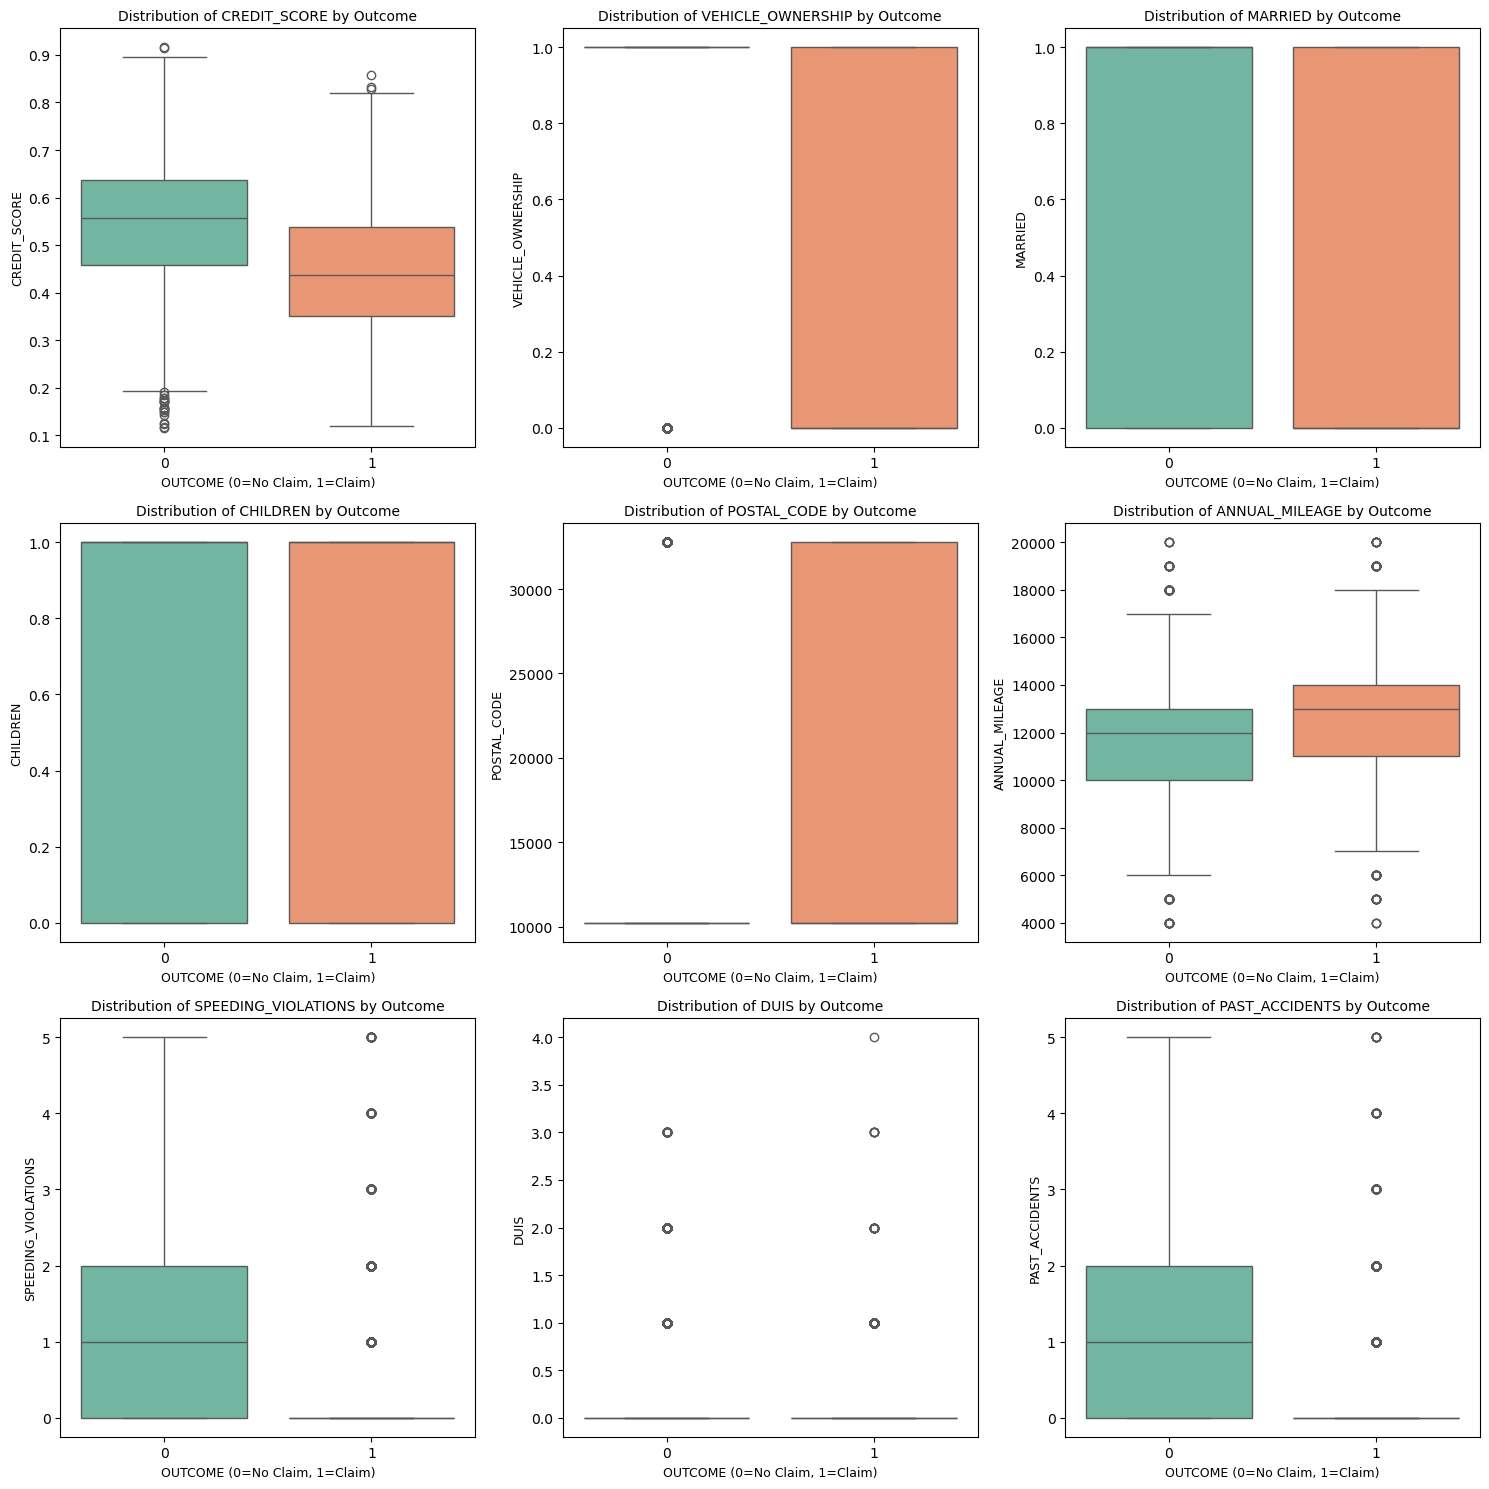

In [ ]:
# مقایسه باکس‌پلات متغیرهای عددی بر اساس خروجی
import matplotlib.pyplot as plt
import seaborn as sns

# ستون‌های عددی به جز OUTCOME
numeric_for_plot = [col for col in numeric_cols if col != 'OUTCOME']

# تعداد ستون‌ها در هر ردیف نمودار
n_cols = 3
n_rows = (len(numeric_for_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
if n_rows == 1 and n_cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, col in enumerate(numeric_for_plot):
    # استفاده از داده‌های پاکسازی‌شده (df_clean)
    sns.boxplot(x='OUTCOME', y=col, data=df_clean, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {col} by Outcome', fontsize=10)
    axes[i].set_xlabel('OUTCOME (0=No Claim, 1=Claim)', fontsize=9)
    axes[i].set_ylabel(col, fontsize=9)

# حذف محورهای خالی اضافی
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
# تحلیل مقایسه ای توزیع متغیرهای عددی بین دو گروه خسارت دیده و ندیده

# CREDIT_SCORE (نمره اعتبار)
# دامنه میان چارکی هر دو ستون تقریبا برابر است
# به نظر میرسد پایین بودن اعتبار رابطه ای مستقیم با سابقه تصادف دارد

# VEHICLE_OWNERSHIP (مالکیت خودرو)
# به نظر میرسد اکثر بیمه گذار ها مالک خودرو نیز هستند
# ممکن است عدم مالکیت خودرو باعث کاهش گزارش تصادف باشد

# MARRIED (وضعیت تأهل)
# متغیری باینری است و تفاوتی بین دو ستون دیده نمیشود

# CHILDREN (فرزندان)
# متغیری باینری است و تفاوتی بین دو ستون دیده نمیشود

# POSTAL_CODE (کدپستی)
# اکثر بیمه گذاران کد پستی دارند ولی کد پستی به تنهایی معیار خوبی برای تشخیص نیست

# ANNUAL_MILEAGE (مسافت سالانه)
# میانه گروه خسارت‌دیده کمی بالاتر از گروه بدون خسارت است
# رانندگی بیشتر (مسافت بالاتر) با افزایش ریسک خسارت همراه است

# SPEEDING_VIOLATIONS (تعداد تخلفات سرعت)
# نقاط پرت (۳، ۴، ۵) فقط در گروه خسارت‌دیده دیده می‌شود
# تخلفات سرعت، یکی از قوی‌ترین پیش‌بیننده‌های خسارت است

# DUIS (تعداد رانندگی در حالت مستی)
# مشابه تخلفات سرعت، میانه هر دو گروه 0 است، اما گروه خسارت‌دیده دارای جعبه‌ای بالاتر و نقاط پرت بیشتری است
# افراد با سابقه در گروه خسارت‌دیده بسیار بیشتر دیده می‌شوند

# PAST_ACCIDENTS (تعداد تصادفات گذشته)
# نقاط پرت (۴، ۵) فقط در گروه خسارت‌دیده وجود دارد
# تعداد تصادفات گذشته شاخصی قوی برای پیش‌بینی خسارت آتی است

# جمع‌بندی
# SPEEDING_VIOLATIONS, DUIS, PAST_ACCIDENTS بیشترین تفاوت را بین دو گروه دارند
# CREDIT_SCORE و ANNUAL_MILEAGE تاثیر متوسطی دارند
# POSTAL_CODE و VEHICLE_OWNERSHIP تفاوت آشکاری نشان نمیدهند

In [ ]:
# بالانس کردن داده ها بر اساس ستون اعلام خسارت
from sklearn.utils import resample

# به دو کلاس رکورد ها رو جدا میکنیم
df_class_0 = df_clean[df_clean['OUTCOME'] == 0]   # کلاس بدون خسارت (اکثریت)
df_class_1 = df_clean[df_clean['OUTCOME'] == 1]   # کلاس با خسارت (اقلیت)

print(f"Before balancing => Class 0: {len(df_class_0)}, Class 1: {len(df_class_1)}")

# کاهش کلاس اکثریت به تعداد کلاس اقلیت
df_class_0_downsampled = resample(
    df_class_0,
    replace=False,                 # نمونه‌گیری بدون جایگذاری
    n_samples=len(df_class_1),     # تعداد برابر با کلاس اقلیت
    random_state=42                # برای بازتولیدپذیری
)

# ترکیب و درهم‌آمیختن
df_balanced = pd.concat([df_class_0_downsampled, df_class_1], axis=0)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"After balancing => Class 0: {len(df_balanced[df_balanced['OUTCOME']==0])}, Class 1: {len(df_balanced[df_balanced['OUTCOME']==1])}")
print(f"Balanced dataset size: {len(df_balanced)}")

Before balancing => Class 0: 5832, Class 1: 2870
After balancing => Class 0: 2870, Class 1: 2870
Balanced dataset size: 5740


In [ ]:
# تبدیل متغیر های غیر عددی به عددی

# جدا کردن ویژگی‌ها و متغیر هدف
X = df_balanced.drop('OUTCOME', axis=1)   # تمام ستون‌ها به جز هدف
y = df_balanced['OUTCOME']                # متغیر هدف

# تبدیل ستون‌های دسته‌ای
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Shape before encoding: {X.shape}")
print(f"Shape after One‑Hot encoding: {X_encoded.shape}")
print("Columns in encoded DataFrame:")
print(X_encoded.columns.tolist())

Shape before encoding: (5740, 16)
Shape after One‑Hot encoding: (5740, 23)
Columns in encoded DataFrame:
['CREDIT_SCORE', 'VEHICLE_OWNERSHIP', 'MARRIED', 'CHILDREN', 'POSTAL_CODE', 'ANNUAL_MILEAGE', 'SPEEDING_VIOLATIONS', 'DUIS', 'PAST_ACCIDENTS', 'AGE_26-39', 'AGE_40-64', 'AGE_65+', 'GENDER_male', 'DRIVING_EXPERIENCE_10-19y', 'DRIVING_EXPERIENCE_20-29y', 'DRIVING_EXPERIENCE_30y+', 'EDUCATION_none', 'EDUCATION_university', 'INCOME_poverty', 'INCOME_upper class', 'INCOME_working class', 'VEHICLE_YEAR_before 2015', 'VEHICLE_TYPE_sports car']


In [ ]:
# داده ها را به دو دسته آموزش و آزمون تقسیم میکنیم
# 25 درصد برای آزمون
# 75 درصد برای آموزش

from sklearn.model_selection import train_test_split

# X_encoded و y باید از مرحله قبل موجود باشند
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.25,
    random_state=42,       # بازتولیدپذیری
    stratify=y             # حفظ نسبت کلاس‌ها در هر دو مجموعه
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Training set size: 4305 samples
Test set size:     1435 samples

Train class distribution:
OUTCOME
1    2153
0    2152
Name: count, dtype: int64

Test class distribution:
OUTCOME
0    718
1    717
Name: count, dtype: int64


In [ ]:
# برای مقایسه بهتر مدل ها عدد تصادفی هر دو 42 داده شده است

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# مدل درخت تصميم
from sklearn.tree import DecisionTreeClassifier

# نرمال‌سازی داده‌ها برای یکنواختی انجام می‌شود
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ايجاد و آموزش مدل درخت تصميم
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# پيش‌بينى بر روى مجموعه آزمون
y_pred_dt = dt_model.predict(X_test_scaled)

# ارزيابى مدل
print("Decision Tree Results")
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {acc_dt:.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No Claim (0)', 'Claim (1)']))

Decision Tree Results
Accuracy: 0.7624

Confusion Matrix:
[[548 170]
 [171 546]]

Classification Report:
              precision    recall  f1-score   support

No Claim (0)       0.76      0.76      0.76       718
   Claim (1)       0.76      0.76      0.76       717

    accuracy                           0.76      1435
   macro avg       0.76      0.76      0.76      1435
weighted avg       0.76      0.76      0.76      1435



In [15]:
# مدل SVM

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# از داده ها کپی میگیریم تا روی داده های اصلی تغیری اعمال نشود
X_train_filled = X_train.copy()
X_test_filled  = X_test.copy()

# مقادیر خالی را با میانه پر میکنیم
num_cols = X_train_filled.select_dtypes(include=[np.number]).columns
imputer_num = SimpleImputer(strategy='median')
X_train_filled[num_cols] = imputer_num.fit_transform(X_train_filled[num_cols])
X_test_filled[num_cols]  = imputer_num.transform(X_test_filled[num_cols])

# در ستون های دسته ای مقدار های خالی را با پرتکرار ترین مقدار جایگزین میکنیم
cat_cols = X_train_filled.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X_train_filled[cat_cols] = imputer_cat.fit_transform(X_train_filled[cat_cols])
    X_test_filled[cat_cols]  = imputer_cat.transform(X_test_filled[cat_cols])

# مقیاس بندی انجام میدهیم
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled  = scaler.transform(X_test_filled)

# مدل را آموزش میدهیم
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# ارزیابی مدل
y_pred_svm = svm_model.predict(X_test_scaled)

print("Linear SVM Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['No Claim (0)', 'Claim (1)']))

Linear SVM Results
Accuracy: 0.8397

Confusion Matrix:
[[586 132]
 [ 98 619]]

Classification Report:
              precision    recall  f1-score   support

No Claim (0)       0.86      0.82      0.84       718
   Claim (1)       0.82      0.86      0.84       717

    accuracy                           0.84      1435
   macro avg       0.84      0.84      0.84      1435
weighted avg       0.84      0.84      0.84      1435



In [16]:
# مقایسه دقت دو مدل

# مدل اس وی ام برتری واضحی از خود نسبت به مدل درخت تصمیم نشان داده است
# مدل اس وی ام در ماتریکس در هر ریختگی خطا های کمتری نشان میدهد
# به طور کلی اس وی ام نتایج بهتر و قابل اعتماد تری برای پیش بینی خسارت ارایه کرده است

Feature Importances (sorted):
                  Feature  Importance
             CREDIT_SCORE    0.182769
           PAST_ACCIDENTS    0.175812
        VEHICLE_OWNERSHIP    0.109922
           ANNUAL_MILEAGE    0.102002
 VEHICLE_YEAR_before 2015    0.067094
              POSTAL_CODE    0.066180
DRIVING_EXPERIENCE_10-19y    0.059462
      SPEEDING_VIOLATIONS    0.053316
              GENDER_male    0.026726
                 CHILDREN    0.024936
                  MARRIED    0.022857
DRIVING_EXPERIENCE_20-29y    0.016653
     EDUCATION_university    0.014953
                AGE_26-39    0.011758
                     DUIS    0.011501
       INCOME_upper class    0.011081
     INCOME_working class    0.008559
           EDUCATION_none    0.008416
                AGE_40-64    0.008208
           INCOME_poverty    0.006143
  VEHICLE_TYPE_sports car    0.005467
  DRIVING_EXPERIENCE_30y+    0.003149
                  AGE_65+    0.003038


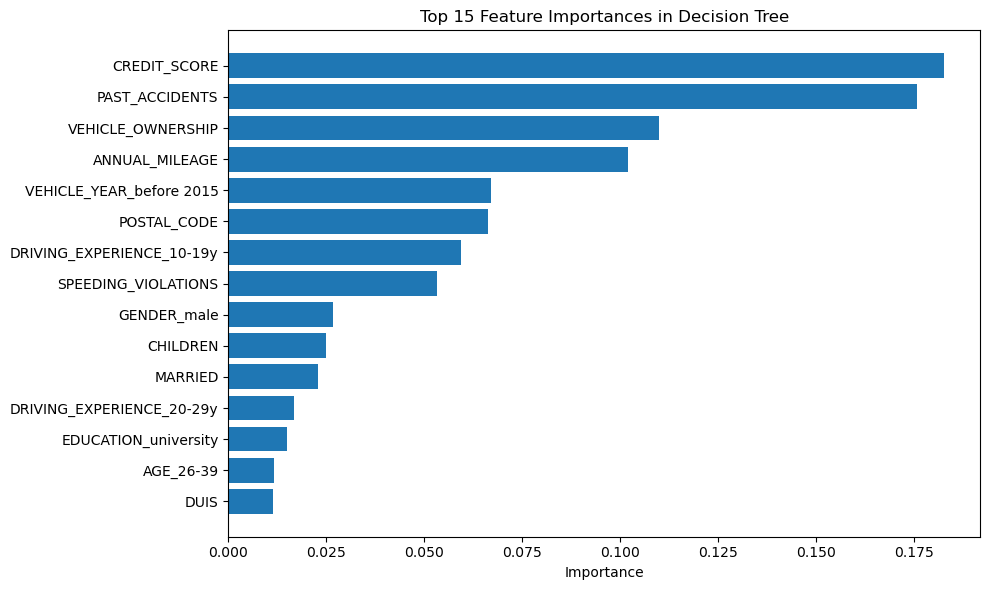

In [ ]:
# محاسبه و نمايش اهميت متغيرها در مدل درخت تصميم

# استخراج نام ویژگی‌ها از متغیر های استفاده شده در مرحله قبل
feature_names = X_encoded.columns

# استخراج اهمیت‌ها از درخت تصميم آموزش‌دیده
importances = dt_model.feature_importances_

# مرتب سازی با استفاده از یک دیتافریم
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# ویژگی های برتر را چاپ میکنیم
print("Feature Importances (sorted):")
print(importance_df.to_string(index=False))

# برای مقایسه راحت تر نمودار میله ای آنها را نیز چاپ میکنیم
top_n = min(15, len(importance_df))
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'].head(top_n)[::-1], importance_df['Importance'].head(top_n)[::-1])
plt.xlabel('Importance')
plt.title(f'Top {top_n} Feature Importances in Decision Tree')
plt.tight_layout()
plt.show()

In [ ]:
# جست و جوی بهترین پارامتر ها برای مدل اس وی ام

from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.svm import SVC
from tqdm.notebook import tqdm   # نوار پيشرفت برای ژوپيتر

# فضاى جستجو براى پارامترها
param_grid = {
    'C': [0.1, 1, 10, 100],            # پارامتر تنظيم
    'gamma': [0.001, 0.01, 0.1, 1],    # ضريب هسته 
    'kernel': ['linear', 'rbf']        # نوع هسته
}

# تمام ترکيب‌هاى ممکن
grid = list(ParameterGrid(param_grid))  

best_score = -np.inf
best_params = None

# حلقه بر روى تمام ترکيب‌ها
for params in tqdm(grid, desc="Grid Search"):
    svm = SVC(**params, random_state=42)
    # اعتبارسنجى متقابل و محاسبه ميانگين دقت
    scores = cross_val_score(svm, X_train_scaled, y_train, cv=5,
                             scoring='accuracy', n_jobs=-1)
    mean_score = scores.mean()
    if mean_score > best_score:
        best_score = mean_score
        best_params = params

print("\nBest parameters:", best_params)
print("Best CV accuracy: {:.4f}".format(best_score))

# آموزش مدل نهايى با بهترين پارامترها
best_svm = SVC(**best_params, random_state=42)
best_svm.fit(X_train_scaled, y_train)
y_pred = best_svm.predict(X_test_scaled)

# ارزيابى روى مجموعه آزمون
print("\nTest Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Claim (0)', 'Claim (1)']))

Grid Search:   0%|          | 0/32 [00:00<?, ?it/s]


Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'linear'}
Best CV accuracy: 0.8314

Test Accuracy: 0.8397
Confusion Matrix:
 [[586 132]
 [ 98 619]]

Classification Report:
              precision    recall  f1-score   support

No Claim (0)       0.86      0.82      0.84       718
   Claim (1)       0.82      0.86      0.84       717

    accuracy                           0.84      1435
   macro avg       0.84      0.84      0.84      1435
weighted avg       0.84      0.84      0.84      1435



In [19]:
# نتیجه گیری کلی پروژه

# مدل اس وی ام برتری واضحی نسبت به درخت تصمیم گیری با 76 درصد دقت دارد
# مدل اس وی ام با ورودی  0.001  و 100  میزان درصد دقتش از 82 به 84 افزایش پیدا کرد
# طبق نتایج بدست آمده سه متغیر تصادفات گذشته و سرعت غیرمجاز و رانندگی در حالت مستی بیشترین عوامل پیش بینی کننده خسارت هستند
# درنهایت این مدل میتواند با ضریب قابل قبولی در پیش بینی مشتریان خطرناک و پر ریسک موفق باشد